# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 06  
**Exercício:** 6A  

---

### Objetivo :  
Implementar para o ambiente da biblioteca gymnasium o algoritmo: 

- Q-LEARNING With Function Approximator

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import gymnasium
import numpy as np
from sklearn.linear_model import SGDRegressor
import sklearn.preprocessing
import sklearn.pipeline
from sklearn.kernel_approximation import RBFSampler
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

## Definição do Ambiente

Considere o seguinte ambiente a ser implementado: 

**Descrição:**

O MDP Mountain car é um MDP deterministico que consiste em um carro situado no fundo de um vale,  
onde possíveis ações de aceleração podem ser aplicadas em duas direções do carro.  
O objetivo é acelerar o carro até o mesmo atingir o topo da montanha.

**Espaço de estados:**  

| Num | Observation                          | Min    | Max    | Unit         |
|-----|--------------------------------------|--------|--------|--------------|
| 0   | position of the car along the x-axis | -1.2   | 0.6    | position (m) |
| 1   | velocity of the car                  | -0.07  | 0.07   | velocity (v) |

**Espaço de ações:**  

0: Acelerar para a esquerda
1: Não acelerar
2: Acelerar para a direita

**Dinâmica de Transição:**  

$ v_{t+1} = v_t + (action - 1) \cdot \text{force} - \cos(3 \cdot x_t) \cdot \text{gravity}$

$x_{t+1} = x_t + v_{t+1}$


**Recompensas:**

O objetivo é atingir o topo da montanha (bandeira amarela) o mais rápido possível, onde o agente é penalizado com recompensa -1 a cada timestep.


**Estado Inicial:**

A posição inicial do carro é um valor que segue uma distribuição aleatória uniforme entre [-0.6,-0.4]. A velocidade é sempre 0.

![GIF](https://gymnasium.farama.org/_images/mountain_car.gif)

### Instanciando o Ambiente

In [2]:
env = gymnasium.make('MountainCar-v0')

### Verificando o Estado e as Ações

In [3]:
print(env.action_space)

Discrete(3)


In [4]:
print(env.observation_space)

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)


### Criando um Episódio Teste

In [5]:
print('---------------------------')
state = env.reset()[0]
print(f"Estado Atual: (Posicao:{state[0]:.4f},Velocidade:{state[1]:.4f})")

action = 2
next_state, reward, done, truncated,_ = env.step(action)

print(f"Próximo estado: (Posicao:{next_state[0]:.4f},Velocidade:{next_state[1]:.4f})")
print(f"Recompensa: {reward}")
print(f"Finalizado: {done}")
print('---------------------------')

---------------------------
Estado Atual: (Posicao:-0.5694,Velocidade:0.0000)
Próximo estado: (Posicao:-0.5681,Velocidade:0.0013)
Recompensa: -1.0
Finalizado: False
---------------------------


In [6]:
v1 = state[1] + (action-1)*0.001 - np.cos(3*state[0])*0.0025
p1 = state[0]+ v1

In [7]:
print(f'posicao_t1: {p1:.4f}')
print(f'velocidade_t1: {v1:.4f}')
state = next_state

posicao_t1: -0.5681
velocidade_t1: 0.0013


## Definição do approximator

In [8]:
class Approximator:

  def __init__(self,env):

    self.env = env
    self.models = []
    self.scaler = sklearn.preprocessing.StandardScaler()
    self.observations =\
     np.array([env.observation_space.sample() for x in range(10000)])
    self.scaler.fit(self.observations)

    self.featurizer = sklearn.pipeline.FeatureUnion([
        ("rbf1", RBFSampler(gamma=5.0, n_components=100)),
        ("rbf2", RBFSampler(gamma=2.0, n_components=100)),
        ("rbf3", RBFSampler(gamma=1.0, n_components=100)),
        ("rbf4", RBFSampler(gamma=0.5, n_components=100))
        ])
    self.featurizer.fit(self.scaler.transform(self.observations))

    # para cada acao
    for _ in range(env.action_space.n):
      model =  SGDRegressor(learning_rate="constant")
      model.partial_fit([self.feature_scale(self.env.reset()[0])],[0])
      self.models.append(model)

  def feature_scale(self,state):
    scaled = self.scaler.transform([state])
    featurized = self.featurizer.transform(scaled)
    return featurized[0]

  def predict(self,state):
    scaled = self.feature_scale(state)
    values = np.array([model.predict([scaled]) for model in self.models])
    return values

  def train(self,state,action,y):
    scaled = self.feature_scale(state)
    self.models[action].partial_fit([scaled],[y])

## Definição do Agente

**Algoritmo:**

Para cada episódio :

1. Inicialize o estado:

2. Enquanto o episódio não terminar:

   a. Com probabilidade, escolha uma ação aleatória  
      Senão, escolha $a = \argmax_a Q(s, a)$
   
   b. Execute a ação $ a $, observe a recompensa $ r $ e o novo estado $  s' $

   c. Atualize o alvo (target):  
  
   $y = r + \gamma \max_{a'} Q(s', a')$
  

   d. Atualize (treine) o approximator para reduzir o erro entre $ Q(s, a) $ e $ y $

   e. $ s \leftarrow s'$

In [9]:
class Agent:

  def __init__(self,env,approximator,epsilon):
    self.env = env
    self.approximator = approximator
    self.epsilon = epsilon
    self.newEpsilon = epsilon

  def epsilon_greedy_policy(self,state):
    A = np.ones(env.action_space.n,dtype=float)*self.newEpsilon/env.action_space.n
    q_values = self.approximator.predict(state)
    best_action = np.argmax(q_values)
    A[best_action] += (1.0 - self.newEpsilon)
    return A


  def q_learning(self,numOfEpisodes,gamma,epsilonDecay):

    lenOfEachEpisode      = np.zeros(numOfEpisodes)
    TotalRewardperEpisode = np.zeros(numOfEpisodes)

    for eps in range(numOfEpisodes):

      #epsilon decay
      self.newEpsilon = self.epsilon*epsilonDecay**eps

      state = self.env.reset()[0]

      done = False
      truncated = False

      print(f'Episode: {eps}/{numOfEpisodes}')
      timestep = 0
      while not done and not truncated:

        action = np.random.choice(env.action_space.n,
                 p=self.epsilon_greedy_policy(state))

        next_state,reward,done,truncated,_ = self.env.step(action)

        TotalRewardperEpisode[eps] += reward
        lenOfEachEpisode[eps] = timestep

        q_values_next_state = self.approximator.predict(next_state)

        td_target = reward + gamma*np.max(q_values_next_state)

        self.approximator.train(state,action,td_target)

        state = next_state
        timestep += 1

    return (lenOfEachEpisode,TotalRewardperEpisode)

## Instanciando as Classes

In [10]:
approximator = Approximator(env)

In [11]:
approximator.models

[SGDRegressor(learning_rate='constant'),
 SGDRegressor(learning_rate='constant'),
 SGDRegressor(learning_rate='constant')]

In [12]:
A = Agent(env,approximator,0.1)

## Aplicando o Algoritmo

In [13]:
metadata = A.q_learning(numOfEpisodes=100,gamma=1.0,epsilonDecay=1.0)

Episode: 0/100
Episode: 1/100
Episode: 2/100
Episode: 3/100
Episode: 4/100
Episode: 5/100
Episode: 6/100
Episode: 7/100
Episode: 8/100
Episode: 9/100
Episode: 10/100
Episode: 11/100
Episode: 12/100
Episode: 13/100
Episode: 14/100
Episode: 15/100
Episode: 16/100
Episode: 17/100
Episode: 18/100
Episode: 19/100
Episode: 20/100
Episode: 21/100
Episode: 22/100
Episode: 23/100
Episode: 24/100
Episode: 25/100
Episode: 26/100
Episode: 27/100
Episode: 28/100
Episode: 29/100
Episode: 30/100
Episode: 31/100
Episode: 32/100
Episode: 33/100
Episode: 34/100
Episode: 35/100
Episode: 36/100
Episode: 37/100
Episode: 38/100
Episode: 39/100
Episode: 40/100
Episode: 41/100
Episode: 42/100
Episode: 43/100
Episode: 44/100
Episode: 45/100
Episode: 46/100
Episode: 47/100
Episode: 48/100
Episode: 49/100
Episode: 50/100
Episode: 51/100
Episode: 52/100
Episode: 53/100
Episode: 54/100
Episode: 55/100
Episode: 56/100
Episode: 57/100
Episode: 58/100
Episode: 59/100
Episode: 60/100
Episode: 61/100
Episode: 62/100
Ep

## Visualização

In [14]:
def plotLenOverTime(metadata):
    # Plot the episode length over time
    fig1 = plt.figure(figsize=(6,2))
    plt.plot(metadata)
    plt.xlabel("Episodio")
    plt.ylabel("Timestep")
    plt.title("Tamanho do episodio pelo tempo")
    plt.show(fig1)

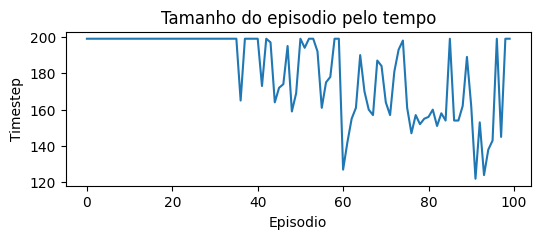

In [15]:
plotLenOverTime(metadata[0])

In [16]:
def plotMeanRewardOverTime(metadata, slide_window=10):

    # Plot the episode reward over time
    plt.figure(figsize=(6,2))
    rewards_smoothed = pd.Series(metadata).rolling(slide_window,
                                   min_periods=slide_window).mean()
    plt.plot(rewards_smoothed)
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa media")
    plt.title(f"Media Movel de Recompensas")
    plt.show()

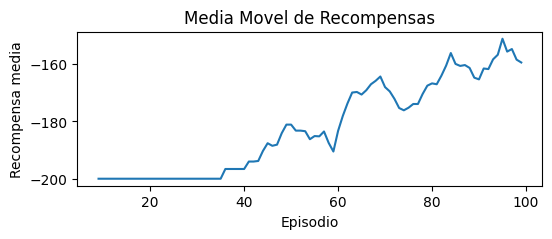

In [17]:
plotMeanRewardOverTime(metadata[1])

In [18]:
def plot_cost_to_go_mountain_car(env, approximator, num_tiles=20):
    x = np.linspace(env.observation_space.low[0], env.observation_space.high[0], num=num_tiles)
    y = np.linspace(env.observation_space.low[1], env.observation_space.high[1], num=num_tiles)
    X, Y = np.meshgrid(x, y)
    Z = np.apply_along_axis(lambda _: -np.max(approximator.predict(_)), 2, np.dstack([X, Y]))

    Z_min = np.min(Z)
    Z_max = np.max(Z)

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                           cmap=matplotlib.cm.coolwarm, vmin=Z_min, vmax=Z_max)
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel('Value')
    ax.set_title("Mountain \"Cost To Go\" Function")
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()

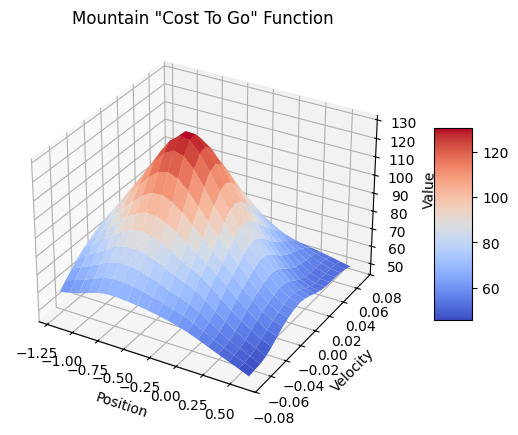

In [19]:
plot_cost_to_go_mountain_car(env, approximator)